In [1]:
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.data_preprocessing import DataPreprocessor
from src.eda_utils import EDAUtils

sns.set_style("whitegrid")

In [2]:
processor = DataPreprocessor(raw_path="../data/raw/")

df_credit = (
    processor.load_data("creditcard.csv")
    .assess_quality()
    .fix_data_types()
    .handle_missing()
    .remove_duplicates()  # This removes identical rows (API retry errors)
    .save("../data/processed/creditcard_cleaned.csv")
    .get_data()
)

2026-06-07 19:47:00,069 - INFO - Loaded: creditcard.csv | Shape: (284807, 31)



DATA QUALITY ASSESSMENT

 BASIC INFO:
   Rows: 284,807
   Columns: 31

DUPLICATES:
   1081 rows (0.38%) based on complete row match

MISSING VALUES:
   None

FIXING DATA TYPES
  Converted target 'Class' → int

HANDLING MISSING VALUES
No missing values to handle.

REMOVING DUPLICATES
  Result: Dropped identical transaction rows (likely API retry errors).
  Removed 1081 duplicate records. Current row count: 283,726


2026-06-07 19:47:08,316 - INFO - Saved cleanly processed data to: ../data/processed/creditcard_cleaned.csv


In [3]:
print(f"\nFinal shape: {df_credit.shape}")
df_credit.head()


Final shape: (283726, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


#### Dataset Overview


In [4]:
print("\n" + "="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Shape: {df_credit.shape[0]:,} rows, {df_credit.shape[1]} columns")
print(f"Time range: {df_credit['Time'].min():.0f} to {df_credit['Time'].max():.0f} seconds")
print(f"Transaction amount range: ${df_credit['Amount'].min():.2f} to ${df_credit['Amount'].max():.2f}")
print(f"Fraud transactions: {df_credit['Class'].sum():,}")
print(f"Legit transactions: {(df_credit['Class'] == 0).sum():,}")


DATASET OVERVIEW
Shape: 283,726 rows, 31 columns
Time range: 0 to 172792 seconds
Transaction amount range: $0.00 to $25691.16
Fraud transactions: 473
Legit transactions: 283,253


#### Class Imbalance Analysis


CLASS IMBALANCE: Credit Card Fraud Data
Class 0: 283,253 (99.8333%)
Class 1: 473 (0.1667%)
Imbalance Ratio: 1:598.8


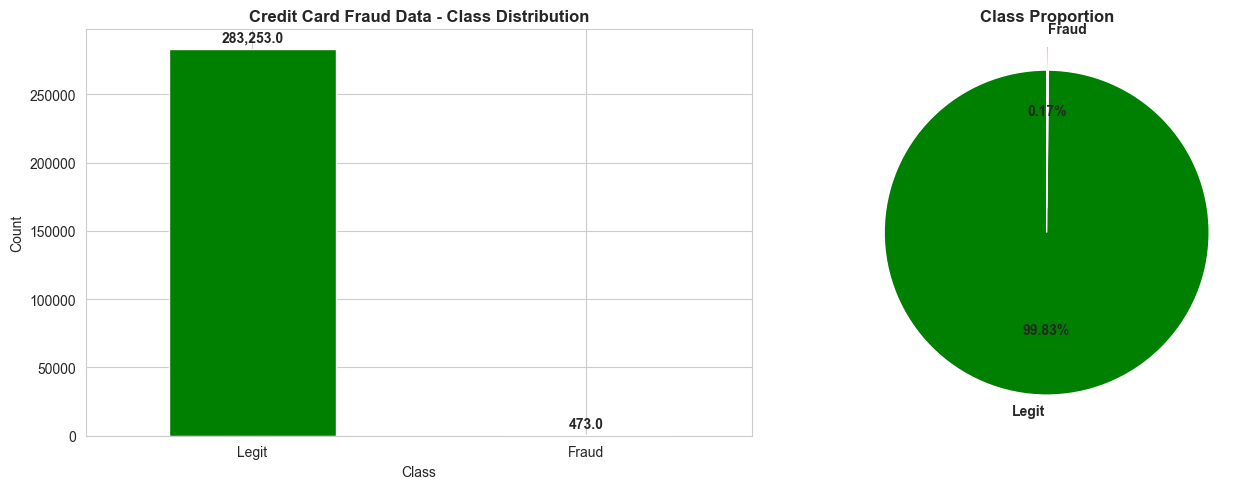

In [5]:
eda = EDAUtils(df_credit, name="Credit Card Fraud Data", target_col='Class')
counts, percentages = eda.class_imbalance()
eda.plot_class_distribution()

#### Univariate Analysis


AMOUNT ANALYSIS


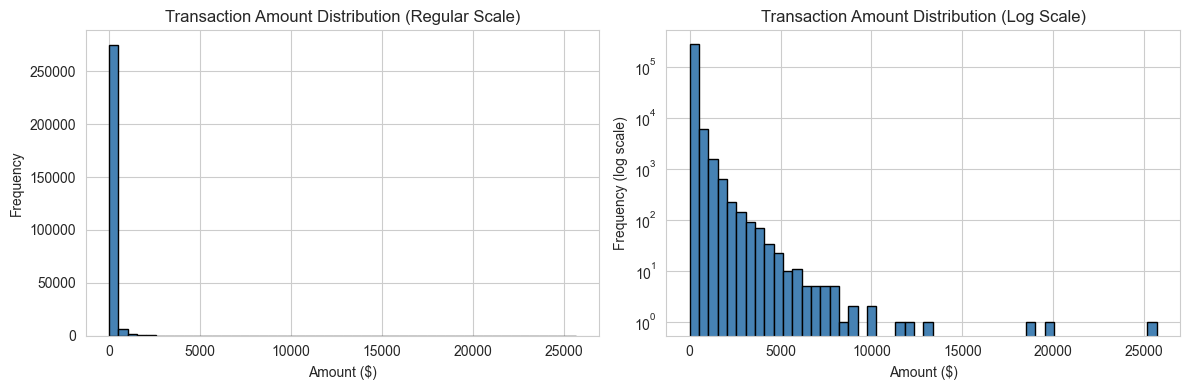


Amount Statistics:
  Mean: $88.47
  Median: $22.00
  99th percentile: $1018.97
  Max: $25691.16


In [6]:

print("\n" + "="*60)
print("AMOUNT ANALYSIS")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Regular scale
df_credit['Amount'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Transaction Amount Distribution (Regular Scale)')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')

# Log scale (more insightful)
df_credit['Amount'].hist(bins=50, ax=axes[1], color='steelblue', edgecolor='black', log=True)
axes[1].set_title('Transaction Amount Distribution (Log Scale)')
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Frequency (log scale)')

plt.tight_layout()
plt.show()

print(f"\nAmount Statistics:")
print(f"  Mean: ${df_credit['Amount'].mean():.2f}")
print(f"  Median: ${df_credit['Amount'].median():.2f}")
print(f"  99th percentile: ${df_credit['Amount'].quantile(0.99):.2f}")
print(f"  Max: ${df_credit['Amount'].max():.2f}")


TIME ANALYSIS


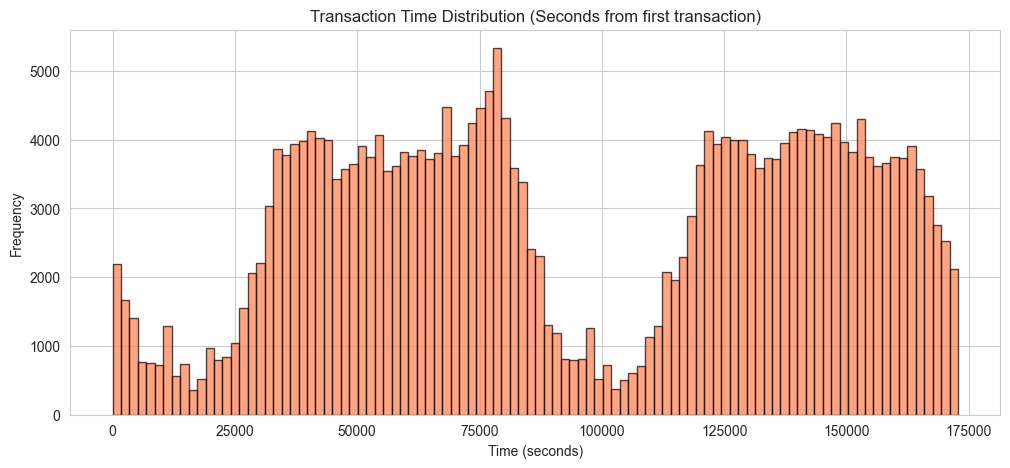


Time Statistics:
  Mean: 94811 seconds
  Median: 84692 seconds
  Duration: 48.0 hours


In [7]:

print("\n" + "="*60)
print("TIME ANALYSIS")
print("="*60)

fig, ax = plt.subplots(figsize=(12, 5))

df_credit['Time'].hist(bins=100, ax=ax, color='coral', edgecolor='black', alpha=0.7)
ax.set_title('Transaction Time Distribution (Seconds from first transaction)')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Frequency')

plt.show()

print(f"\nTime Statistics:")
print(f"  Mean: {df_credit['Time'].mean():.0f} seconds")
print(f"  Median: {df_credit['Time'].median():.0f} seconds")
print(f"  Duration: {(df_credit['Time'].max() - df_credit['Time'].min())/3600:.1f} hours")

Numerical Summary of PCA Features

In [8]:
pca_cols = ['V1', 'V2', 'V3', 'V4', 'V5', 'Amount', 'Time']
eda.numerical_summary(pca_cols)


NUMERICAL FEATURES: Credit Card Fraud Data
           count          mean           std         min           25%  \
V1      283726.0      0.005917      1.948026  -56.407510     -0.915951   
V2      283726.0     -0.004135      1.646703  -72.715728     -0.600321   
V3      283726.0      0.001613      1.508682  -48.325589     -0.889682   
V4      283726.0     -0.002966      1.414184   -5.683171     -0.850134   
V5      283726.0      0.001828      1.377008 -113.743307     -0.689830   
Amount  283726.0     88.472687    250.399437    0.000000      5.600000   
Time    283726.0  94811.077600  47481.047891    0.000000  54204.750000   

                 50%            75%            max  
V1          0.020384       1.316068       2.454930  
V2          0.063949       0.800283      22.057729  
V3          0.179963       1.026960       9.382558  
V4         -0.022248       0.739647      16.875344  
V5         -0.053468       0.612218      34.801666  
Amount     22.000000      77.510000   25691.1

#### Bivariate Analysis


AMOUNT BY CLASS


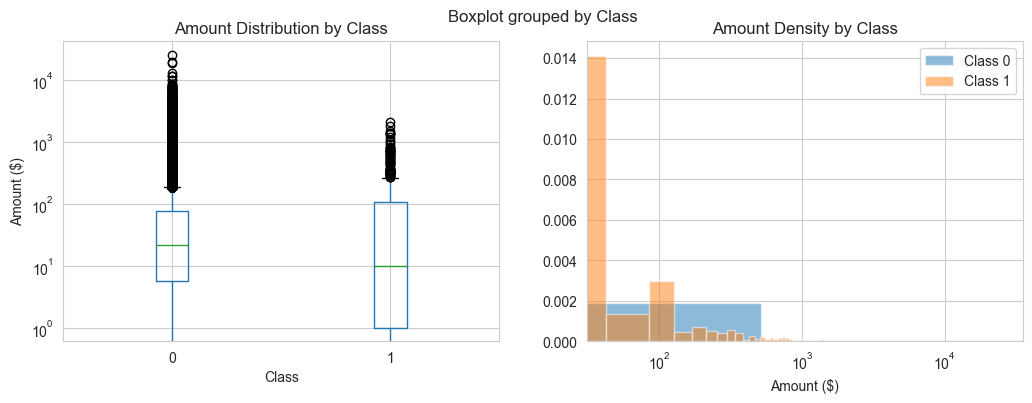


Amount Statistics:
Legit - Mean: $88.41
Fraud - Mean: $123.87
Legit - Median: $22.00
Fraud - Median: $9.82


In [9]:
print("\n" + "="*60)
print("AMOUNT BY CLASS")
print("="*60)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Box plot
df_credit.boxplot(column='Amount', by='Class', ax=axes[0])
axes[0].set_title('Amount Distribution by Class')
axes[0].set_ylabel('Amount ($)')
axes[0].set_yscale('log')

# Histogram
for label in [0, 1]:
    subset = df_credit[df_credit['Class'] == label]['Amount']
    axes[1].hist(subset, bins=50, alpha=0.5, label=f'Class {label}', density=True)
axes[1].set_title('Amount Density by Class')
axes[1].set_xlabel('Amount ($)')
axes[1].legend()
axes[1].set_xscale('log')

plt.show()

# Print statistics
print("\nAmount Statistics:")
print(f"Legit - Mean: ${df_credit[df_credit['Class']==0]['Amount'].mean():.2f}")
print(f"Fraud - Mean: ${df_credit[df_credit['Class']==1]['Amount'].mean():.2f}")
print(f"Legit - Median: ${df_credit[df_credit['Class']==0]['Amount'].median():.2f}")
print(f"Fraud - Median: ${df_credit[df_credit['Class']==1]['Amount'].median():.2f}")


TIME DISTRIBUTION BY CLASS


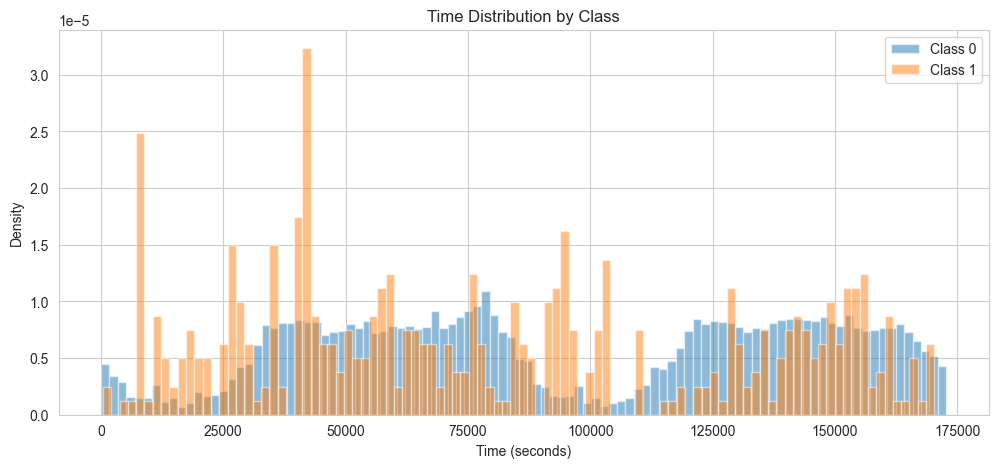

In [10]:
print("\n" + "="*60)
print("TIME DISTRIBUTION BY CLASS")
print("="*60)

fig, ax = plt.subplots(figsize=(12, 5))

for label in [0, 1]:
    subset = df_credit[df_credit['Class'] == label]['Time']
    ax.hist(subset, bins=100, alpha=0.5, label=f'Class {label}', density=True)
ax.set_title('Time Distribution by Class')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Density')
ax.legend()

plt.show()

#### PCA Features Analysis (Top Correlations)

In [11]:
top_pca = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14']
corr_df = eda.correlation_with_target(top_pca + ['Amount', 'Time'])


CORRELATION WITH TARGET: Credit Card Fraud Data
  V14: -0.2934
  V12: -0.2507
  V10: -0.2070
  V3: -0.1823
  V7: -0.1723
  V11: 0.1491
  V4: 0.1293
  V1: -0.0945
  V9: -0.0940
  V5: -0.0878


Top 15 features: ['V14', 'V12', 'V10', 'V3', 'V7', 'V11', 'V4', 'V1', 'V9', 'V5', 'V2', 'V6', 'V8', 'Time', 'Amount']


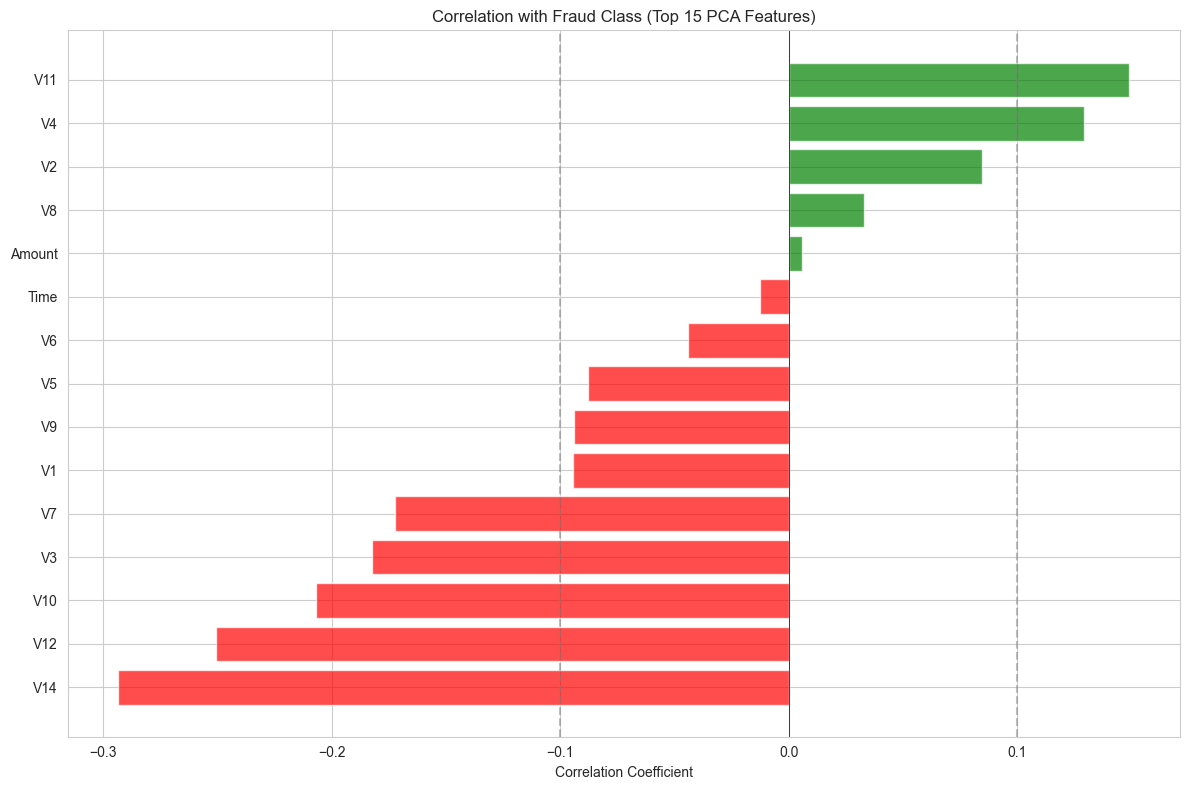


CORRELATION SUMMARY
Strongest positive correlation: 0.1491 (V11)
Strongest negative correlation: -0.2934 (V14)
Features with |correlation| > 0.15: 5


In [17]:
#  correlation matrix for top PCA features
# Get top 15 by absolute correlation
top_15_features = corr_df.head(15)['feature'].tolist()
print(f"Top 15 features: {top_15_features}")

# Create correlation matrix
cols_to_plot = top_15_features + ['Class']
corr_matrix = df_credit[cols_to_plot].corr()

# Plot only correlations with Class (more focused)
plt.figure(figsize=(12, 8))

# Extract correlations with Class
class_corr = corr_matrix['Class'].drop('Class').sort_values()

# Horizontal bar plot (cleaner than heatmap for this use case)
colors = ['red' if x < 0 else 'green' for x in class_corr.values]
plt.barh(class_corr.index, class_corr.values, color=colors, alpha=0.7)
plt.axvline(x=0, color='black', linewidth=0.5)
plt.axvline(x=0.1, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=-0.1, color='gray', linestyle='--', alpha=0.5)
plt.title('Correlation with Fraud Class (Top 15 PCA Features)', fontsize=12)
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

# Summary
print("\n" + "="*60)
print("CORRELATION SUMMARY")
print("="*60)
print(f"Strongest positive correlation: {class_corr.max():.4f} ({class_corr.idxmax()})")
print(f"Strongest negative correlation: {class_corr.min():.4f} ({class_corr.idxmin()})")
print(f"Features with |correlation| > 0.15: {(class_corr.abs() > 0.15).sum()}")

TIME DISTRIBUTION ANALYSIS
KS Test Statistic: 0.1604
P-value: 4.4676e-11
CONCLUSION: Fraud and legitimate transactions have SIGNIFICANTLY different time distributions

TIME SEGMENT STATISTICS
              fraud_rate  total_transactions  fraud_count  fraud_rate_pct
time_segment                                                             
0-4h              0.0040                9533           38            0.40
4-12h             0.0029               37663          109            0.29
12-24h            0.0013               97039          126            0.13
24-36h            0.0018               47292           85            0.18
36-48h            0.0012               92197          110            0.12


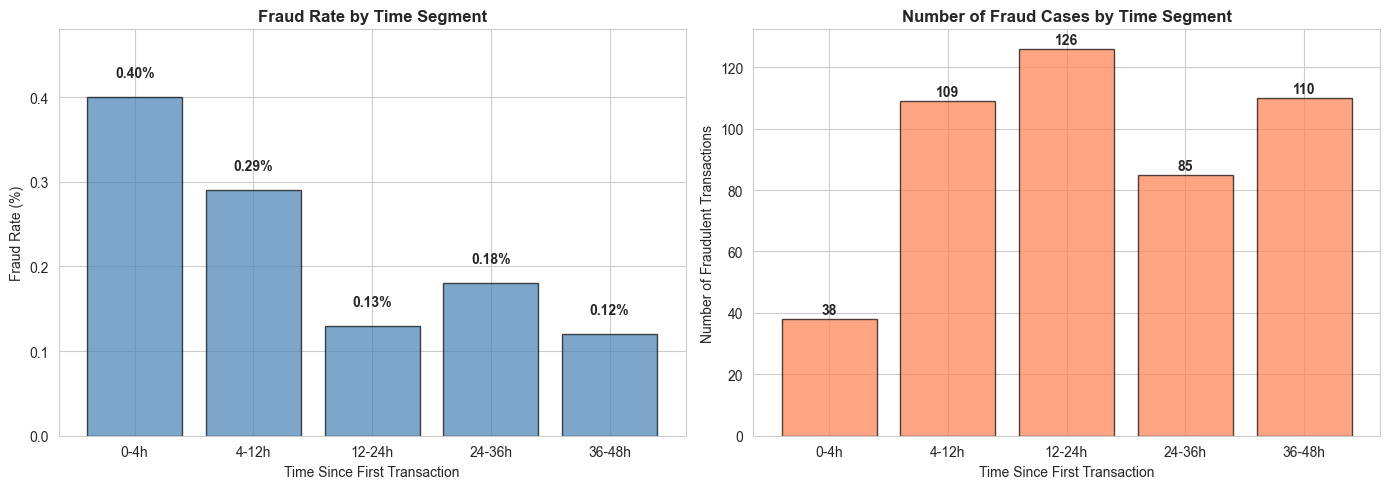


KEY INSIGHT
 Highest fraud risk: 0-4h after first transaction (0.400% fraud rate)
   This is 3.3x higher than lowest risk period


In [18]:
# Cell: Better time segment analysis
from scipy.stats import ks_2samp

legit_times = df_credit[df_credit['Class'] == 0]['Time']
fraud_times = df_credit[df_credit['Class'] == 1]['Time']

ks_stat, p_value = ks_2samp(legit_times, fraud_times)

print("="*60)
print("TIME DISTRIBUTION ANALYSIS")
print("="*60)
print(f"KS Test Statistic: {ks_stat:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("CONCLUSION: Fraud and legitimate transactions have SIGNIFICANTLY different time distributions")
else:
    print("CONCLUSION: No significant difference in time distributions")

# Better time segmentation with actual counts
time_bins = [0, 14400, 43200, 86400, 129600, 172800]  # 4h, 12h, 24h, 36h, 48h
time_labels = ['0-4h', '4-12h', '12-24h', '24-36h', '36-48h']
df_credit['time_segment'] = pd.cut(df_credit['Time'], bins=time_bins, labels=time_labels)

# Get both fraud rate AND count
segment_stats = df_credit.groupby('time_segment').agg({
    'Class': ['mean', 'count']
}).round(4)
segment_stats.columns = ['fraud_rate', 'total_transactions']
segment_stats['fraud_count'] = (segment_stats['fraud_rate'] * segment_stats['total_transactions']).astype(int)
segment_stats['fraud_rate_pct'] = segment_stats['fraud_rate'] * 100

print("\n" + "="*60)
print("TIME SEGMENT STATISTICS")
print("="*60)
print(segment_stats.to_string())

# visualization with dual axes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Fraud rate by segment (with proper scaling)
bars = ax1.bar(
    segment_stats.index, 
    segment_stats['fraud_rate_pct'],
    color='steelblue',
    edgecolor='black',
    alpha=0.7
)
ax1.set_title('Fraud Rate by Time Segment', fontsize=12, fontweight='bold')
ax1.set_xlabel('Time Since First Transaction')
ax1.set_ylabel('Fraud Rate (%)')
ax1.set_ylim(0, max(segment_stats['fraud_rate_pct']) * 1.2)

# Add labels on bars
for bar, rate in zip(bars, segment_stats['fraud_rate_pct']):
    ax1.text(
        bar.get_x() + bar.get_width()/2., 
        rate + 0.02,
        f'{rate:.2f}%',
        ha='center', 
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Plot 2: Fraud count by segment (to show sample size)
bars2 = ax2.bar(
    segment_stats.index,
    segment_stats['fraud_count'],
    color='coral',
    edgecolor='black',
    alpha=0.7
)
ax2.set_title('Number of Fraud Cases by Time Segment', fontsize=12, fontweight='bold')
ax2.set_xlabel('Time Since First Transaction')
ax2.set_ylabel('Number of Fraudulent Transactions')

# Add labels on bars
for bar, count in zip(bars2, segment_stats['fraud_count']):
    ax2.text(
        bar.get_x() + bar.get_width()/2., 
        count + 0.5,
        f'{count}',
        ha='center', 
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

# Key insight
print("\n" + "="*60)
print("KEY INSIGHT")
print("="*60)
peak_segment = segment_stats['fraud_rate_pct'].idxmax()
peak_rate = segment_stats['fraud_rate_pct'].max()
print(f" Highest fraud risk: {peak_segment} after first transaction ({peak_rate:.3f}% fraud rate)")
print(f"   This is {peak_rate/segment_stats['fraud_rate_pct'].min():.1f}x higher than lowest risk period")